# Stage 1 — Text Understanding (Feature Extraction)

Extracts the signals used later for the evidence reports:
named entities, keywords, sentiment, sensational-language score, hedging-language score, and the core claim of each post.

Builds on `data/processed/train.csv` from the data prep notebook.

## 1. Setup

In [1]:
!pip install -q spacy vaderSentiment


In [2]:
!python -m spacy download en_core_web_sm -q

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nlp = spacy.load("en_core_web_sm")
vader = SentimentIntensityAnalyzer()

## 2. Load processed data

In [8]:

cols = [
    "id", "label", "text", "subject", "speaker",
    "speaker_job", "state", "party",
    "barely_true_count", "false_count", "half_true_count",
    "mostly_true_count", "pants_fire_count", "context"
]

train_df = pd.read_csv("train.tsv", sep="\t", header=None, names=cols)

print(train_df.shape)
print(train_df["label"].value_counts())
train_df.head()

(10240, 14)
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


,id,label,text,subject,speaker,speaker_job,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


## 3. Define the feature extractors

In [9]:
HEDGING_PHRASES = [
    "some say", "sources claim", "many believe", "it is said", "experts say",
    "according to sources", "reportedly", "rumor has it", "people are saying",
    "some experts believe", "unconfirmed reports", "sources close to",
    "allegedly", "many people think",
]

SENSATIONAL_WORDS = [
    "shocking", "breaking", "exposed", "secret", "miracle", "destroyed",
    "outrageous", "unbelievable", "terrifying", "horrifying", "bombshell",
    "scandal", "wake up", "urgent", "warning", "banned", "censored",
    "cover-up", "conspiracy",
]

In [10]:
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents
            if ent.label_ in {"PERSON","ORG","GPE","LOC","DATE","NORP"}]

In [11]:
def extract_keywords(text, top_n=5):
    doc = nlp(text)
    chunks = [c.text.strip().lower() for c in doc.noun_chunks if len(c.text.strip()) > 2]
    seen, keywords = set(), []
    for c in chunks:
        if c not in seen:
            seen.add(c)
            keywords.append(c)
        if len(keywords) >= top_n:
            break
    return keywords

In [12]:
def extract_sentiment(text):
    return vader.polarity_scores(text)

In [13]:
def sensational_score(text):
    text_lower = text.lower()
    triggers = [w for w in SENSATIONAL_WORDS if w in text_lower]
    exclamations = text.count("!")
    all_caps_words = re.findall(r"\b[A-Z]{3,}\b", text)
    score = min(1.0, len(triggers)*0.15 + min(exclamations,5)*0.08 + min(len(all_caps_words),5)*0.05)
    return score

In [14]:
def hedging_score(text):
    text_lower = text.lower()
    found = [p for p in HEDGING_PHRASES if p in text_lower]
    return min(1.0, len(found) * 0.4)

In [15]:
def extract_core_claim(text):
    doc = nlp(text)
    for sent in doc.sents:
        has_verb = any(t.pos_ == "VERB" for t in sent)
        has_noun = any(t.pos_ in {"NOUN","PROPN"} for t in sent)
        if has_verb and has_noun:
            return sent.text.strip()
    return text[:200]

## 4. Quick test on one example

In [16]:
sample = ("BREAKING!!! Doctors HATE this miracle cure that BIG PHARMA doesn't "
          "want you to know about. Some experts say it cures everything overnight.")

print("entities:", extract_entities(sample))
print("keywords:", extract_keywords(sample))
print("sentiment:", extract_sentiment(sample))
print("sensational_score:", sensational_score(sample))
print("hedging_score:", hedging_score(sample))
print("claim:", extract_core_claim(sample))

entities: []
keywords: ['breaking', 'doctors', 'this miracle cure', 'big pharma', 'you']
sentiment: {'neg': 0.217, 'neu': 0.633, 'pos': 0.15, 'compound': -0.2572}
sensational_score: 0.74
hedging_score: 0.4
claim: Doctors HATE this miracle cure that BIG PHARMA doesn't want you to know about.


## 5. Apply to a sample of the dataset

Running spaCy over the full 33k rows is slow, so we use a sample for exploration. Swap `sample_df = train_df` to run on everything.

In [24]:
train_df["source"] = "LIAR"
sample_df = train_df.sample(1000, random_state=42).reset_index(drop=True)

sample_df["sensational_score"] = sample_df["text"].apply(sensational_score)
sample_df["hedging_score"] = sample_df["text"].apply(hedging_score)
sample_df["sentiment_compound"] = sample_df["text"].apply(lambda t: extract_sentiment(t)["compound"])

sample_df[["text","label","source","sensational_score","hedging_score","sentiment_compound"]].head()

,text,label,source,sensational_score,hedging_score,sentiment_compound
0,Polling shows that nearly 74 percent of Nation...,true,LIAR,0.0,0.0,0.0772
1,I left the city with $43 million in the bank.,barely-true,LIAR,0.0,0.0,0.0000
2,Says she couldn't take stimulus money because ...,false,LIAR,0.0,0.0,0.0000
3,The United States is the only industrialized c...,mostly-true,LIAR,0.0,0.0,0.6440
4,The Health Care and Education Reconciliation A...,barely-true,LIAR,0.0,0.0,0.4939


## 6. Compare signal scores across labels

In [25]:
print(sample_df.groupby("label")[["sensational_score","hedging_score","sentiment_compound"]].mean())

             sensational_score  hedging_score  sentiment_compound
label                                                            
barely-true           0.006766            0.0            0.002540
false                 0.005297            0.0           -0.049502
half-true             0.008019            0.0           -0.005667
mostly-true           0.007463            0.0           -0.005943
pants-fire            0.007162            0.0            0.039973
true                  0.004398            0.0           -0.045228


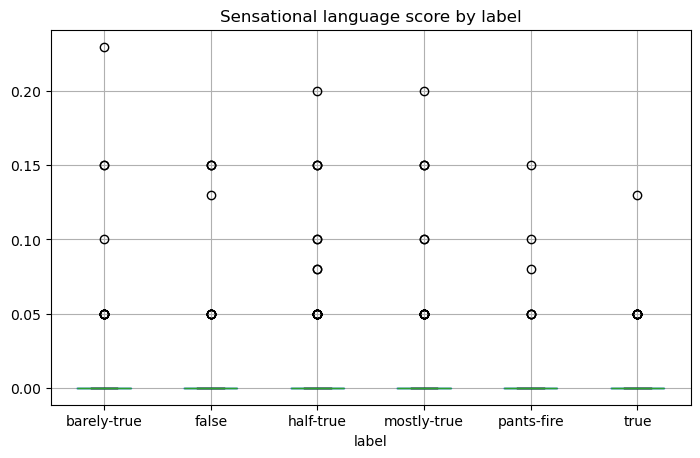

In [26]:
sample_df.boxplot(column="sensational_score", by="label", figsize=(8,5))
plt.suptitle("")
plt.title("Sensational language score by label")
plt.show()

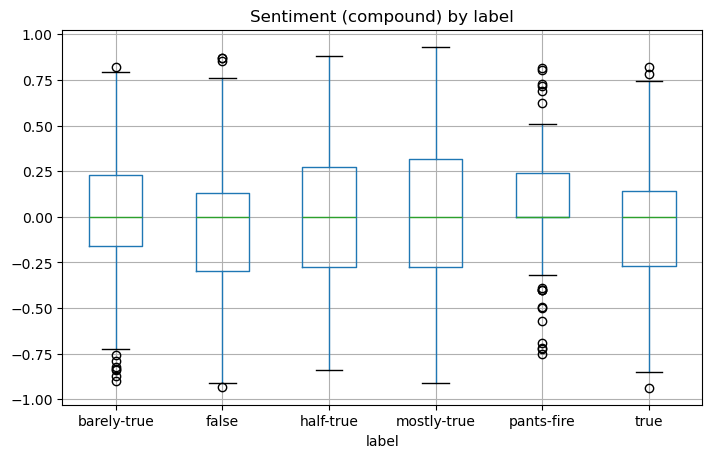

In [22]:
sample_df.boxplot(column="sentiment_compound", by="label", figsize=(8,5))
plt.suptitle("")
plt.title("Sentiment (compound) by label")
plt.show()

## 7. Compare across source too

Since LIAR (short claims) and Kaggle (long articles) behave differently, worth checking whether these scores are also driven by source rather than label.

In [27]:
print(sample_df.groupby("source")[["sensational_score","hedging_score","sentiment_compound"]].mean())

        sensational_score  hedging_score  sentiment_compound
source                                                      
LIAR              0.00653            0.0           -0.015651


## 8. Save sample features (optional, for inspection / report)

In [28]:
import os
os.makedirs("outputs", exist_ok=True)
sample_df.to_csv("outputs/stage1_feature_sample.csv", index=False)
print("saved outputs/stage1_feature_sample.csv")

saved outputs/stage1_feature_sample.csv
